## Environment setup

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that.

In [ ]:
!nvidia-smi

### Install dependencies

Installs RF-DETR version 1.2.1 or higher (which includes the new Nano, Small, and Medium checkpoints), along with Supervision for benchmarking and Roboflow for pulling datasets and uploading models to the Roboflow platform.

In [ ]:
!pip install -q rfdetr==1.2.1 supervision==0.26.1 roboflow

In [1]:
import os
from zipfile import ZipFile

In [2]:
path = os.getcwd()
print(path)

d:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Model_Code\RF-DETR


In [3]:
# Create the directory if it doesn't exist
extract_dir = "data"
os.makedirs(extract_dir, exist_ok=True)

with ZipFile("Glass Defect Detection.v3i.coco.zip", "r") as data_set:
    data_set.extractall(extract_dir)

In [10]:
DATA_YAML = "data/config.yaml"
data_set_dir = path+"/data"

## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [6]:
from rfdetr import RFDETRNano
# 
# model = RFDETRNano()

In [ ]:
model.train(dataset_dir=data_set_dir, epochs=100, batch_size=4, grad_accum_steps=4)

In [ ]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [ ]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [ ]:
cleanup_gpu_memory(model, verbose=True)

We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRMedium` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [7]:
model = RFDETRNano(pretrain_weights="checkpoint_best_total.pth")
model.optimize_for_inference()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 2 classes, but your model has 90 classes
reinitializing detection head with 2 classes


Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [11]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{data_set_dir}/test",
    annotations_path=f"{data_set_dir}/test/_annotations.coco.json",
)

In [12]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision
from PIL import Image
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 173/173 [00:16<00:00, 10.29it/s]


In [13]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.595
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.841
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.557
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.232
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.337
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = 0.947


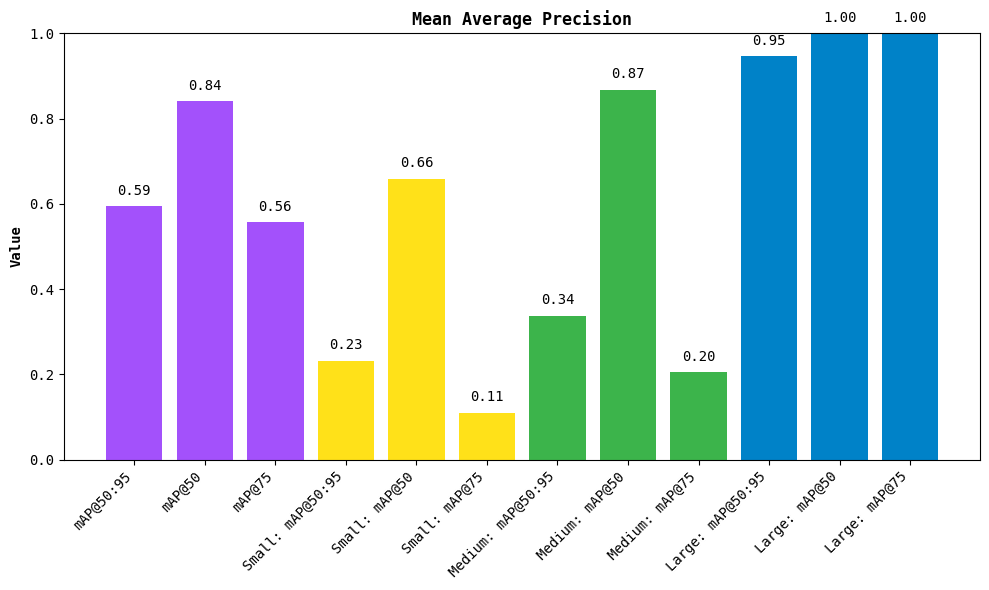

In [14]:
map_result.plot()

## Run Inference with Fine-tuned RF-DETR Model

In [ ]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

In [ ]:
from supervision.metrics import F1Score, Precision, Recall

f1 = F1Score()
prec = Precision()
rec = Recall()

f1 = f1.update(predictions, targets).compute()
prec = prec.update(predictions, targets).compute()
rec = rec.update(predictions, targets).compute()

f1.plot()
prec.plot()
rec.plot()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Daten ---
# Die Reihenfolge der Werte entspricht den Beschriftungen auf der X-Achse
precision_values = np.array([0.02, 0.01, 0.01, 0.00, 0.02, 0.01, 0.44, 0.44])
recall_values = np.array([0.90, 0.59, 0.77, 0.21, 0.60, 0.30, 1.00, 1.00])
f1_values = np.array([0.03, 0.03, 0.02, 0.01, 0.04, 0.02, 0.61, 0.61])

# Beschriftungen für die X-Achse
labels = [
    'Precision@50', 'Precision@75',
    'Small: P@50', 'Small: P@75',
    'Medium: P@50', 'Medium: P@75',
    'Large: P@50', 'Large: P@75'
]

# Beschriftungen für Recall und F1 anpassen
recall_labels = [label.replace('Precision', 'Recall').replace('P@', 'R@') for label in labels]
f1_labels = [label.replace('Precision', 'F1 Score').replace('P@', 'F1@') for label in labels]

# --- 2. Farben und Plot-Konfiguration ---
# Farben: Lila, Gelb, Grün, Blau
colors = (
    ['mediumpurple'] * 2 +
    ['gold'] * 2 +
    ['forestgreen'] * 2 +
    ['dodgerblue'] * 2
)

# Metriken in einer Liste für die Iteration
plots_data = [
    {"title": "Precision, by Object Size\n(target: boxes, averaging: weighted)", "values": precision_values, "labels": labels, "filename": "precision_plot.png"},
    {"title": "Recall, by Object Size\n(target: boxes, averaging: weighted)", "values": recall_values, "labels": recall_labels, "filename": "recall_plot.png"},
    {"title": "F1 Score, by Object Size\n(target: boxes, averaging: weighted)", "values": f1_values, "labels": f1_labels, "filename": "f1_score_plot.png"}
]

# --- 3. Plot-Funktion mit Labels IM Balken ---
def create_bar_chart(values, labels, title):
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['mediumpurple', 'blueviolet', 'gold', 'gold', 'forestgreen', 'forestgreen', 'dodgerblue', 'dodgerblue'])

    # Passen Sie die X-Achsen-Beschriftungen an (wie im Originalbild)
    plt.xticks(rotation=30, ha='right') 

    plt.title('Recall, by IoU (Target: boxes, averaging: weighted)')
    plt.ylabel('Value')
    plt.ylim(0, 1.05) # Stellt sicher, dass alle Balken vollständig sichtbar sind

    for bar in bars:
            yval = bar.get_height()
            
            # Schwellenwert für die Platzierung: Wenn Balkenhöhe >= 0.10
            if yval >= 0.10:
                # Label INNEN (Weiß)
                plt.text(
                    bar.get_x() + bar.get_width()/2, 
                    yval - 0.05,        # 5% unterhalb der Spitze
                    f"{yval:.2f}",
                    ha='center', va='top', 
                    fontsize=10, color='white', fontweight='bold'
                )
            else:
                # Label AUSSEN (Schwarz)
                plt.text(
                    bar.get_x() + bar.get_width()/2, 
                    yval + 0.01,        # 1% oberhalb der Spitze
                    f"{yval:.2f}",
                    ha='center', va='bottom', 
                    fontsize=10, color='black', fontweight='bold'
                )
    plt.tight_layout() # Stellt sicher, dass die Labels nicht abgeschnitten werden
    plt.title(title)
    plt.savefig('custom_recall_plot.png')
    plt.show()

    print("Das benutzerdefinierte Balkendiagramm mit Labels im Balken wurde gespeichert.")
    plt.close()

# --- 4. Plots generieren ---
for data in plots_data:
    create_bar_chart( data["values"], data["labels"], data["title"])

print("Die Diagramme 'precision_plot.png', 'recall_plot.png' und 'f1_score_plot.png' wurden gespeichert.")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 3x3 Matrix Data ---
# Classes: 0=defect, 1=glass, 2=Background

# Row 0 (True: defect)
# P: defect (141), P: glass (1), P: Background (FN = 55)
row_defect = [141, 1, 55] 

# Row 1 (True: glass)
# P: defect (50), P: glass (173), P: Background (FN for glass, assumed 0)
row_glass = [0, 173, 0] 

# Row 2 (True: Background)
# P: defect (FP = 50), P: glass (FP for glass, assumed 0), P: Background (TN, assumed 0)
row_background = [50, 0, 0]

cm_3x3_data = np.array([
    row_defect, 
    row_glass, 
    row_background
])

labels_3x3 = ['defect', 'glass', 'no defect']


# --- 2. Plot the 3x3 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_3x3_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_3x3,
    yticklabels=labels_3x3
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Roboflow')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 3x3 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_3x3_data, index=labels_3x3, columns=labels_3x3)
print(df)

In [ ]:
confusion = sv.ConfusionMatrix.from_detections(predictions, targets)

#### Test every test image to see what the outputs are -> to determine what classes are needed in the confusion matrix

In [ ]:
test_data = "D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluating-Object-Detection-Models/Coding/Model_Code/RF-DETR/Glass Defect Detection.v3i.coco/test"

model = RFDETRNano(pretrain_weights="checkpoint_best_total.pth")

model.optimize_for_inference()

In [ ]:
dataset = sv.DetectionDataset.from_coco(
    images_directory_path=test_data,
    annotations_path= test_data + "/_annotations.coco.json"
)

In [ ]:
from tqdm import tqdm
from PIL import Image

# Annahme: model, dataset, bbox_annotator, label_annotator etc. sind initialisiert.

# Iteriere durch den gesamten Datensatz. 
# tqdm wird zur Anzeige eines Fortschrittsbalkens verwendet.
for i in range(len(dataset)):
    # 1. Daten laden
    path, _, annotations = dataset[i]
    image = Image.open(path).convert("RGB") # Sicherstellen, dass das Bild RGB ist

    # 2. Modelldurchlauf (Inferenz)
    detections = model.predict(image, threshold=0.5)

    # 3. Labels vorbereiten
    # Labels für Ground Truth (nur Klassenname)
    annotations_labels = [
        f"{dataset.classes[class_id]}"
        for class_id
        in annotations.class_id
    ]

    # Labels für Detections (Klassenname und Konfidenz)
    detections_labels = [
        f"{dataset.classes[class_id]} {confidence:.2f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]

    # 4. Annotationen visualisieren (Ground Truth)
    annotation_image = image.copy()
    annotation_image = bbox_annotator.annotate(annotation_image, annotations)
    annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

    # 5. Detections visualisieren (Modellvorhersage)
    detections_image = image.copy()
    detections_image = bbox_annotator.annotate(detections_image, detections)
    detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

    # 6. Bilder darstellen
    # Der Titel enthält den Index des aktuellen Bildes
    sv.plot_images_grid(
        images=[annotation_image, detections_image], 
        grid_size=(1, 2), 
        titles=[f"Bild {i} - Annotation", f"Bild {i} - Detection"]
    )
    
    # HINWEIS: Je nach Umgebung (Jupyter Notebook, Skript) müssen Sie
    # möglicherweise eine Pause (z.B. input() oder time.sleep())
    # einfügen oder die Bilder speichern, da die Anzeige schnell
    # durchlaufen kann.